# 55 - Ground Truth と顔検索精度の定量評価

手動ラベルに基づいて顔検索の精度を定量的に評価する。
クラスタリング結果（Notebook 54）を活用してラベリングを効率化する。

## 入力
- `data/images.duckdb` (face_detections テーブル, cluster_id 設定済み)

## 出力
- Precision@K, Recall@K, MRR, mAP の評価結果
- 最適な類似度閾値の決定
- `face_detections` テーブルの `person_label` 更新

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

## 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")
EMBEDDING_DIM = 512

## Ground Truth ラベリング

### 戦略
1. `terada` カテゴリの全顔に `person_label = 'terada'` を設定
2. terada と同じクラスタに属するカンファレンス写真の顔にも `person_label = 'terada'` を設定
3. 高類似度で terada にマッチする顔を目視確認してラベリング

In [3]:
conn = duckdb.connect(str(DB_PATH))
conn.execute("LOAD vss;")

# Step 1: terada カテゴリの顔に person_label を設定
conn.execute("""
    UPDATE face_detections
    SET person_label = 'terada'
    WHERE image_id IN (
        SELECT id FROM image_catalog WHERE category = 'terada'
    )
""")

# terada のクラスタIDを取得
terada_clusters = conn.execute("""
    SELECT DISTINCT cluster_id
    FROM face_detections
    WHERE person_label = 'terada' AND cluster_id IS NOT NULL
""").fetchdf()

print(f"terada のクラスタID: {terada_clusters['cluster_id'].tolist()}")

# Step 2: 同じクラスタの顔にもラベルを設定
if len(terada_clusters) > 0:
    cluster_ids = terada_clusters['cluster_id'].tolist()
    for cid in cluster_ids:
        conn.execute("""
            UPDATE face_detections
            SET person_label = 'terada'
            WHERE cluster_id = ? AND person_label IS NULL
        """, [int(cid)])

conn.commit()

# ラベリング結果確認
label_stats = conn.execute("""
    SELECT 
        person_label,
        COUNT(*) as count
    FROM face_detections
    GROUP BY person_label
    ORDER BY count DESC
""").fetchdf()

print("\nラベリング結果:")
display(label_stats)

terada のクラスタID: [0]

ラベリング結果:


,person_label,count
0,None,671
1,terada,20


## 高類似度マッチの目視確認と追加ラベリング

terada の Embedding でTop-K 検索し、まだラベルのない高類似度の顔を確認する。

In [4]:
def crop_face(file_path: str, bbox_x1: float, bbox_y1: float, bbox_x2: float, bbox_y2: float, padding: int = 20) -> Image.Image:
    """画像から顔をクロップする"""
    img = Image.open(file_path).convert("RGB")
    x1 = max(0, int(bbox_x1) - padding)
    y1 = max(0, int(bbox_y1) - padding)
    x2 = min(img.width, int(bbox_x2) + padding)
    y2 = min(img.height, int(bbox_y2) + padding)
    return img.crop((x1, y1, x2, y2))

In [5]:
# terada の代表 Embedding を取得 (最高スコアの顔)
terada_emb = conn.execute(f"""
    SELECT f.embedding
    FROM face_detections f
    JOIN image_catalog c ON f.image_id = c.id
    WHERE c.category = 'terada'
    ORDER BY f.det_score DESC
    LIMIT 1
""").fetchone()[0]

# 未ラベルの高類似度顔を検索
unlabeled_matches = conn.execute(f"""
    SELECT 
        f.face_id,
        c.file_name,
        c.file_path,
        c.category,
        f.bbox_x1, f.bbox_y1, f.bbox_x2, f.bbox_y2,
        f.person_label,
        array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}]) as distance
    FROM face_detections f
    JOIN image_catalog c ON f.image_id = c.id
    WHERE f.person_label IS NULL
    ORDER BY distance
    LIMIT 30
""", [[float(x) for x in terada_emb]]).fetchdf()

unlabeled_matches["similarity"] = 1.0 - unlabeled_matches["distance"]

print(f"未ラベルの高類似度顔 Top 30:")
display(unlabeled_matches[["file_name", "category", "similarity"]].head(20))

未ラベルの高類似度顔 Top 30:


,file_name,category,similarity
0,2025-09-27 15.33.31.jpg,PyConJP2025,0.232895
1,2025-09-28 20.07.47.jpg,PyConJP2025,0.184875
2,2025-09-26 19.36.16.jpg,PyConJP2025,0.175234
3,2025-09-27 15.33.31.jpg,PyConJP2025,0.163666
4,2025-09-25 21.21.14.jpg,PyConJP2025,0.159276
5,2025-07-19 01.52.09.jpg,EuroPython2025,0.158951
6,2025-07-19 03.38.46.jpg,EuroPython2025,0.153931
7,2025-07-18 00.25.28.jpg,EuroPython2025,0.146505
8,2025-07-16 23.30.10.jpg,EuroPython2025,0.136859
9,2025-07-19 01.58.40-2.jpg,EuroPython2025,0.135777


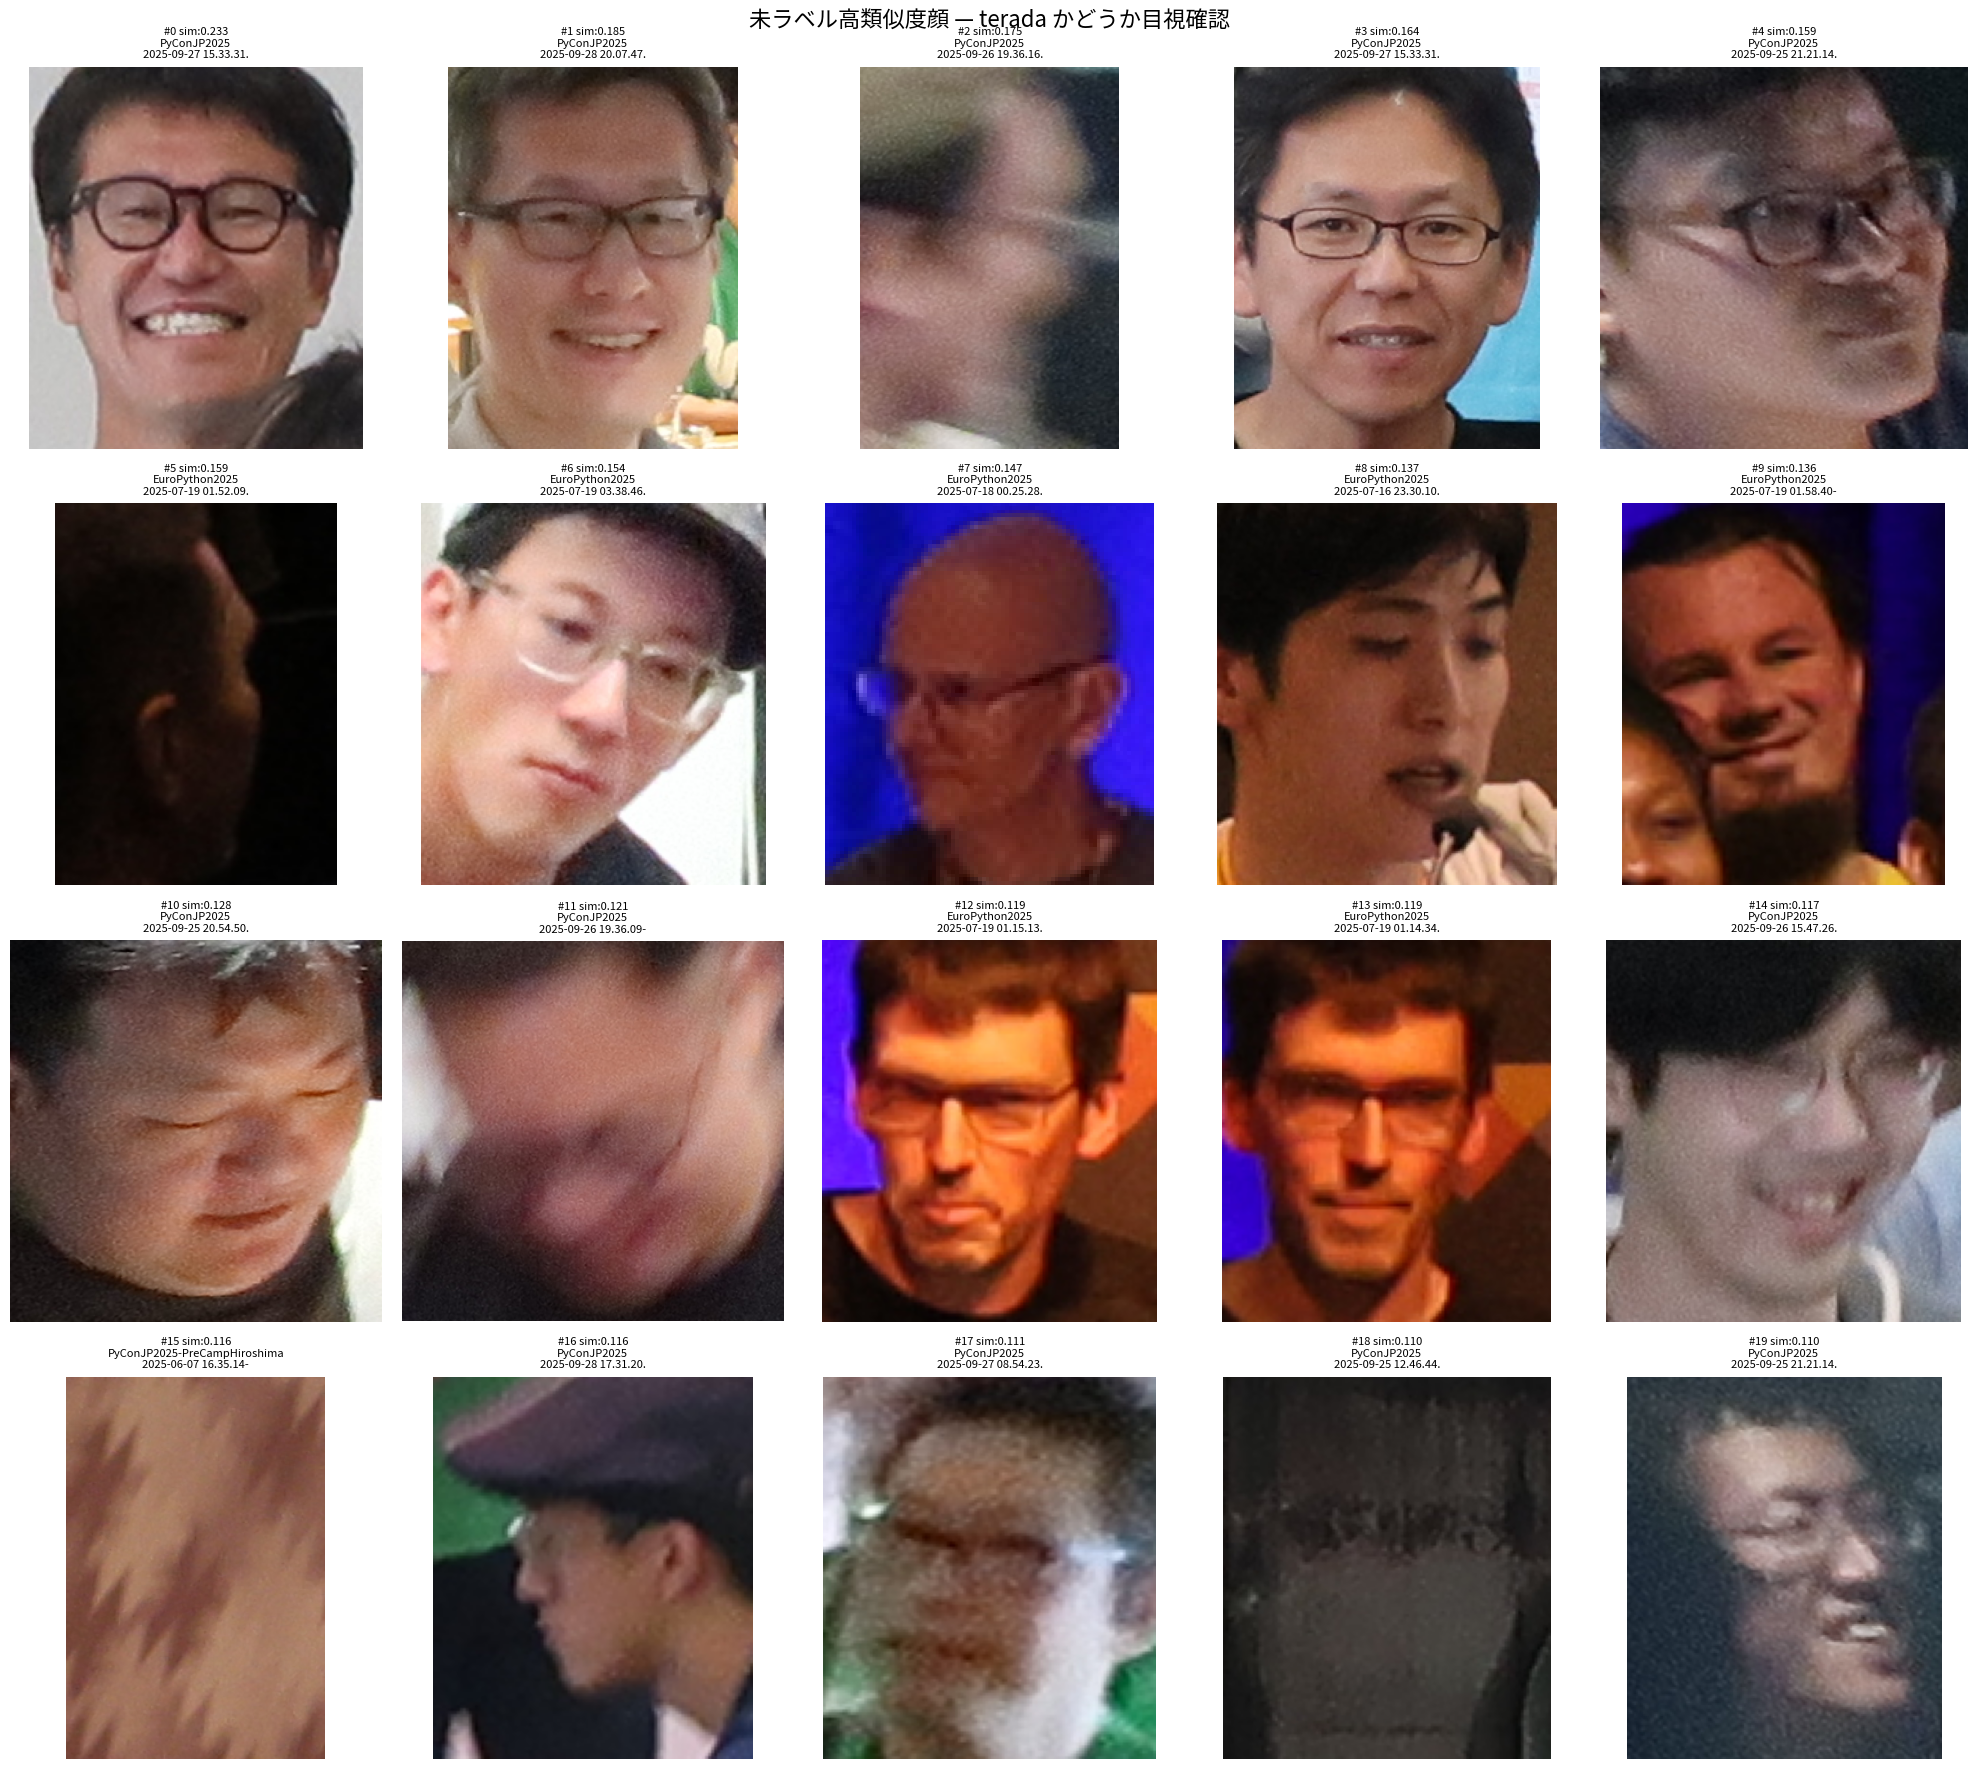


上記の顔を確認し、terada と思われるものの index を以下のセルで指定してください。


In [6]:
# 目視確認用のグリッド表示
n_show = min(20, len(unlabeled_matches))
cols = 5
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.5 * rows))
axes = np.array(axes).flatten()

for idx, (_, row) in enumerate(unlabeled_matches.head(n_show).iterrows()):
    try:
        face_crop = crop_face(row["file_path"], row["bbox_x1"], row["bbox_y1"],
                              row["bbox_x2"], row["bbox_y2"])
        axes[idx].imshow(face_crop)
    except Exception:
        axes[idx].text(0.5, 0.5, "Error", ha="center", va="center", transform=axes[idx].transAxes)

    axes[idx].set_title(
        f"#{idx} sim:{row['similarity']:.3f}\n{row['category']}\n{row['file_name'][:20]}",
        fontsize=8
    )
    axes[idx].axis("off")

for i in range(n_show, len(axes)):
    axes[i].axis("off")

plt.suptitle("未ラベル高類似度顔 — terada かどうか目視確認", fontsize=16)
plt.tight_layout()
plt.show()

print("\n上記の顔を確認し、terada と思われるものの index を以下のセルで指定してください。")

In [7]:
# 目視確認後、terada と判定した顔の index を指定
# （実行時に目視で判断して、このリストを編集してから再実行）
terada_indices = []  # 例: [0, 1, 3, 5]

if terada_indices:
    for idx in terada_indices:
        face_id = unlabeled_matches.iloc[idx]["face_id"]
        conn.execute("""
            UPDATE face_detections
            SET person_label = 'terada'
            WHERE face_id = ?
        """, [face_id])

    conn.commit()
    print(f"{len(terada_indices)} 件の顔に person_label='terada' を設定しました")
else:
    print("追加ラベリングなし（terada_indices が空）")

# 最終ラベリング結果
terada_count = conn.execute("""
    SELECT COUNT(*) FROM face_detections WHERE person_label = 'terada'
""").fetchone()[0]
total_count = conn.execute("SELECT COUNT(*) FROM face_detections").fetchone()[0]
print(f"\nterada ラベル: {terada_count} / {total_count}")

追加ラベリングなし（terada_indices が空）

terada ラベル: 20 / 691


## 定量評価

terada の各ポートレート顔をクエリとして、検索精度を評価する。

### 評価指標
- **Precision@K**: Top-K 結果中の正解率
- **Recall@K**: Top-K 結果で回収された正解の割合
- **MRR (Mean Reciprocal Rank)**: 最初の正解のランク逆数の平均
- **mAP (mean Average Precision)**: 各クエリの Average Precision の平均

In [8]:
# terada ポートレートの顔をクエリとして取得
query_faces = conn.execute(f"""
    SELECT 
        f.face_id, f.embedding, f.det_score,
        c.file_name, c.file_path
    FROM face_detections f
    JOIN image_catalog c ON f.image_id = c.id
    WHERE c.category = 'terada'
    ORDER BY f.det_score DESC
""").fetchdf()

# 画像ごとに最高スコアの顔を1つ選択
query_faces = query_faces.groupby("file_name").first().reset_index()

# 正解の顔IDセット (terada ラベル付き、かつ terada カテゴリ以外)
relevant_faces = conn.execute("""
    SELECT f.face_id
    FROM face_detections f
    JOIN image_catalog c ON f.image_id = c.id
    WHERE f.person_label = 'terada' AND c.category != 'terada'
""").fetchdf()
relevant_set = set(relevant_faces["face_id"])

print(f"クエリ顔数: {len(query_faces)}")
print(f"正解顔数（terada カテゴリ除外）: {len(relevant_set)}")

クエリ顔数: 10
正解顔数（terada カテゴリ除外）: 10


In [9]:
def compute_metrics(ranked_face_ids: list[str], relevant_set: set[str], k_values: list[int]) -> dict:
    """検索結果の評価指標を計算する"""
    results = {}

    # Precision@K, Recall@K
    for k in k_values:
        top_k = ranked_face_ids[:k]
        relevant_in_top_k = sum(1 for fid in top_k if fid in relevant_set)
        results[f"P@{k}"] = relevant_in_top_k / k if k > 0 else 0
        results[f"R@{k}"] = relevant_in_top_k / len(relevant_set) if len(relevant_set) > 0 else 0

    # MRR
    rr = 0
    for rank, fid in enumerate(ranked_face_ids, 1):
        if fid in relevant_set:
            rr = 1.0 / rank
            break
    results["MRR"] = rr

    # Average Precision
    ap = 0
    relevant_count = 0
    for rank, fid in enumerate(ranked_face_ids, 1):
        if fid in relevant_set:
            relevant_count += 1
            ap += relevant_count / rank
    results["AP"] = ap / len(relevant_set) if len(relevant_set) > 0 else 0

    return results

In [10]:
# 各クエリで評価
K_VALUES = [1, 3, 5, 10, 20]
MAX_RESULTS = 100

all_metrics = []

for _, query_row in query_faces.iterrows():
    query_embedding = [float(x) for x in query_row["embedding"]]

    # terada カテゴリ以外の顔で検索
    results = conn.execute(f"""
        SELECT f.face_id
        FROM face_detections f
        JOIN image_catalog c ON f.image_id = c.id
        WHERE c.category != 'terada'
        ORDER BY array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}])
        LIMIT {MAX_RESULTS}
    """, [query_embedding]).fetchdf()

    ranked_ids = results["face_id"].tolist()
    metrics = compute_metrics(ranked_ids, relevant_set, K_VALUES)
    metrics["query"] = query_row["file_name"]
    all_metrics.append(metrics)

df_metrics = pd.DataFrame(all_metrics)
print("クエリ別の評価指標:")
display(df_metrics)

クエリ別の評価指標:


,P@1,R@1,P@3,R@3,P@5,R@5,P@10,R@10,P@20,R@20,MRR,AP,query
0,1.0,0.1,1.0,0.3,1.0,0.5,1.0,1.0,0.5,1.0,1.0,1.0,202203証明写真オリジナル.jpg
1,1.0,0.1,1.0,0.3,1.0,0.5,1.0,1.0,0.5,1.0,1.0,1.0,TeradaPyConJP.jpg
2,1.0,0.1,1.0,0.3,1.0,0.5,1.0,1.0,0.5,1.0,1.0,1.0,terada-2020-square-500.jpg
3,1.0,0.1,1.0,0.3,1.0,0.5,1.0,1.0,0.5,1.0,1.0,1.0,terada-202205-pyconjp-4-3-900.jpg
4,1.0,0.1,1.0,0.3,1.0,0.5,1.0,1.0,0.5,1.0,1.0,1.0,terada-pao-2025.jpg
5,1.0,0.1,1.0,0.3,1.0,0.5,1.0,1.0,0.5,1.0,1.0,1.0,terada-pyconjp2019.jpg
6,1.0,0.1,1.0,0.3,1.0,0.5,1.0,1.0,0.5,1.0,1.0,1.0,terada-uspycon2019-up.jpg
7,1.0,0.1,1.0,0.3,1.0,0.5,1.0,1.0,0.5,1.0,1.0,1.0,terada.jpg
8,1.0,0.1,1.0,0.3,1.0,0.5,1.0,1.0,0.5,1.0,1.0,1.0,terada2.jpg
9,1.0,0.1,1.0,0.3,1.0,0.5,1.0,1.0,0.5,1.0,1.0,1.0,terada_pythonbr_thumb.png


In [11]:
# 平均指標
mean_metrics = df_metrics.drop(columns=["query"]).mean()
print("平均評価指標:")
for metric, value in mean_metrics.items():
    print(f"  {metric}: {value:.4f}")

print(f"\nmAP (mean Average Precision): {mean_metrics['AP']:.4f}")
print(f"MRR (Mean Reciprocal Rank): {mean_metrics['MRR']:.4f}")

平均評価指標:
  P@1: 1.0000
  R@1: 0.1000
  P@3: 1.0000
  R@3: 0.3000
  P@5: 1.0000
  R@5: 0.5000
  P@10: 1.0000
  R@10: 1.0000
  P@20: 0.5000
  R@20: 1.0000
  MRR: 1.0000
  AP: 1.0000

mAP (mean Average Precision): 1.0000
MRR (Mean Reciprocal Rank): 1.0000


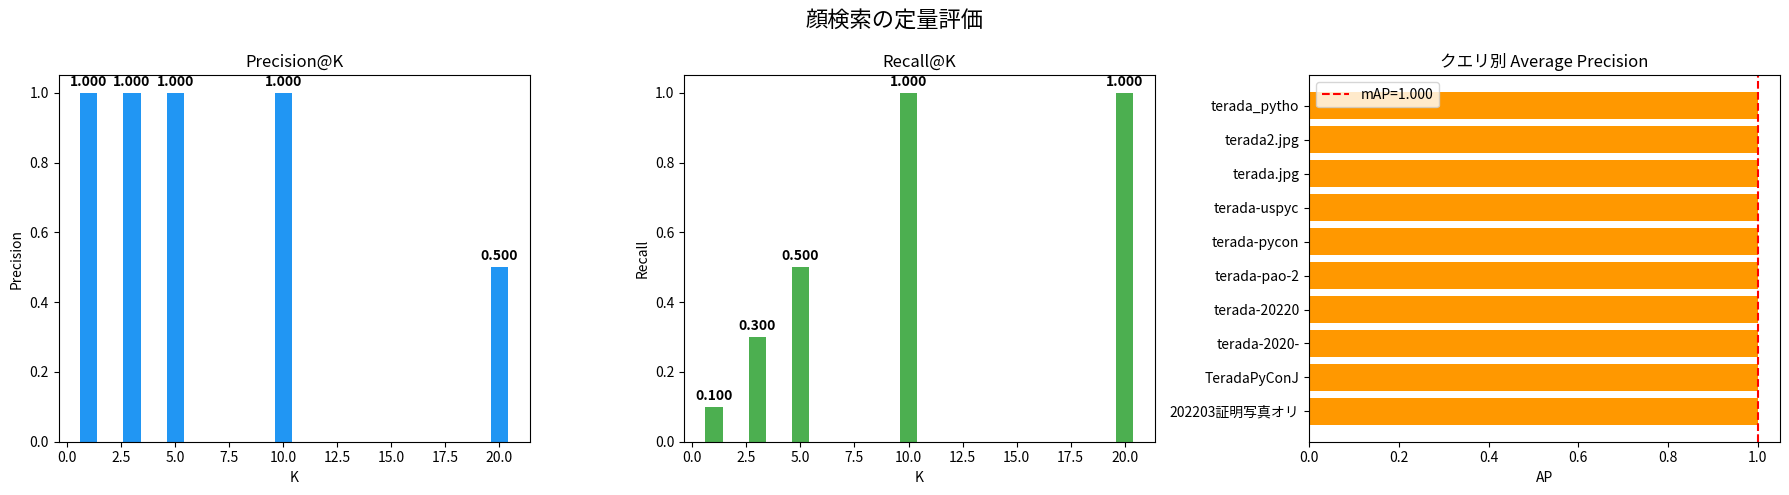

In [12]:
# 可視化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Precision@K
p_cols = [f"P@{k}" for k in K_VALUES]
p_means = [mean_metrics[c] for c in p_cols]
axes[0].bar(K_VALUES, p_means, color="#2196F3")
axes[0].set_title("Precision@K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Precision")
axes[0].set_ylim(0, 1.05)
for k, p in zip(K_VALUES, p_means):
    axes[0].text(k, p + 0.02, f"{p:.3f}", ha="center", fontweight="bold")

# 2. Recall@K
r_cols = [f"R@{k}" for k in K_VALUES]
r_means = [mean_metrics[c] for c in r_cols]
axes[1].bar(K_VALUES, r_means, color="#4CAF50")
axes[1].set_title("Recall@K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1.05)
for k, r in zip(K_VALUES, r_means):
    axes[1].text(k, r + 0.02, f"{r:.3f}", ha="center", fontweight="bold")

# 3. クエリ別 AP
query_names = [q[:12] for q in df_metrics["query"]]
axes[2].barh(query_names, df_metrics["AP"], color="#FF9800")
axes[2].set_title("クエリ別 Average Precision")
axes[2].set_xlabel("AP")
axes[2].set_xlim(0, 1.05)
axes[2].axvline(mean_metrics["AP"], color="red", linestyle="--", label=f"mAP={mean_metrics['AP']:.3f}")
axes[2].legend()

plt.suptitle("顔検索の定量評価", fontsize=16)
plt.tight_layout()
plt.show()

## False Positive / False Negative の分析

Top-20 結果: TP=10, FP=10


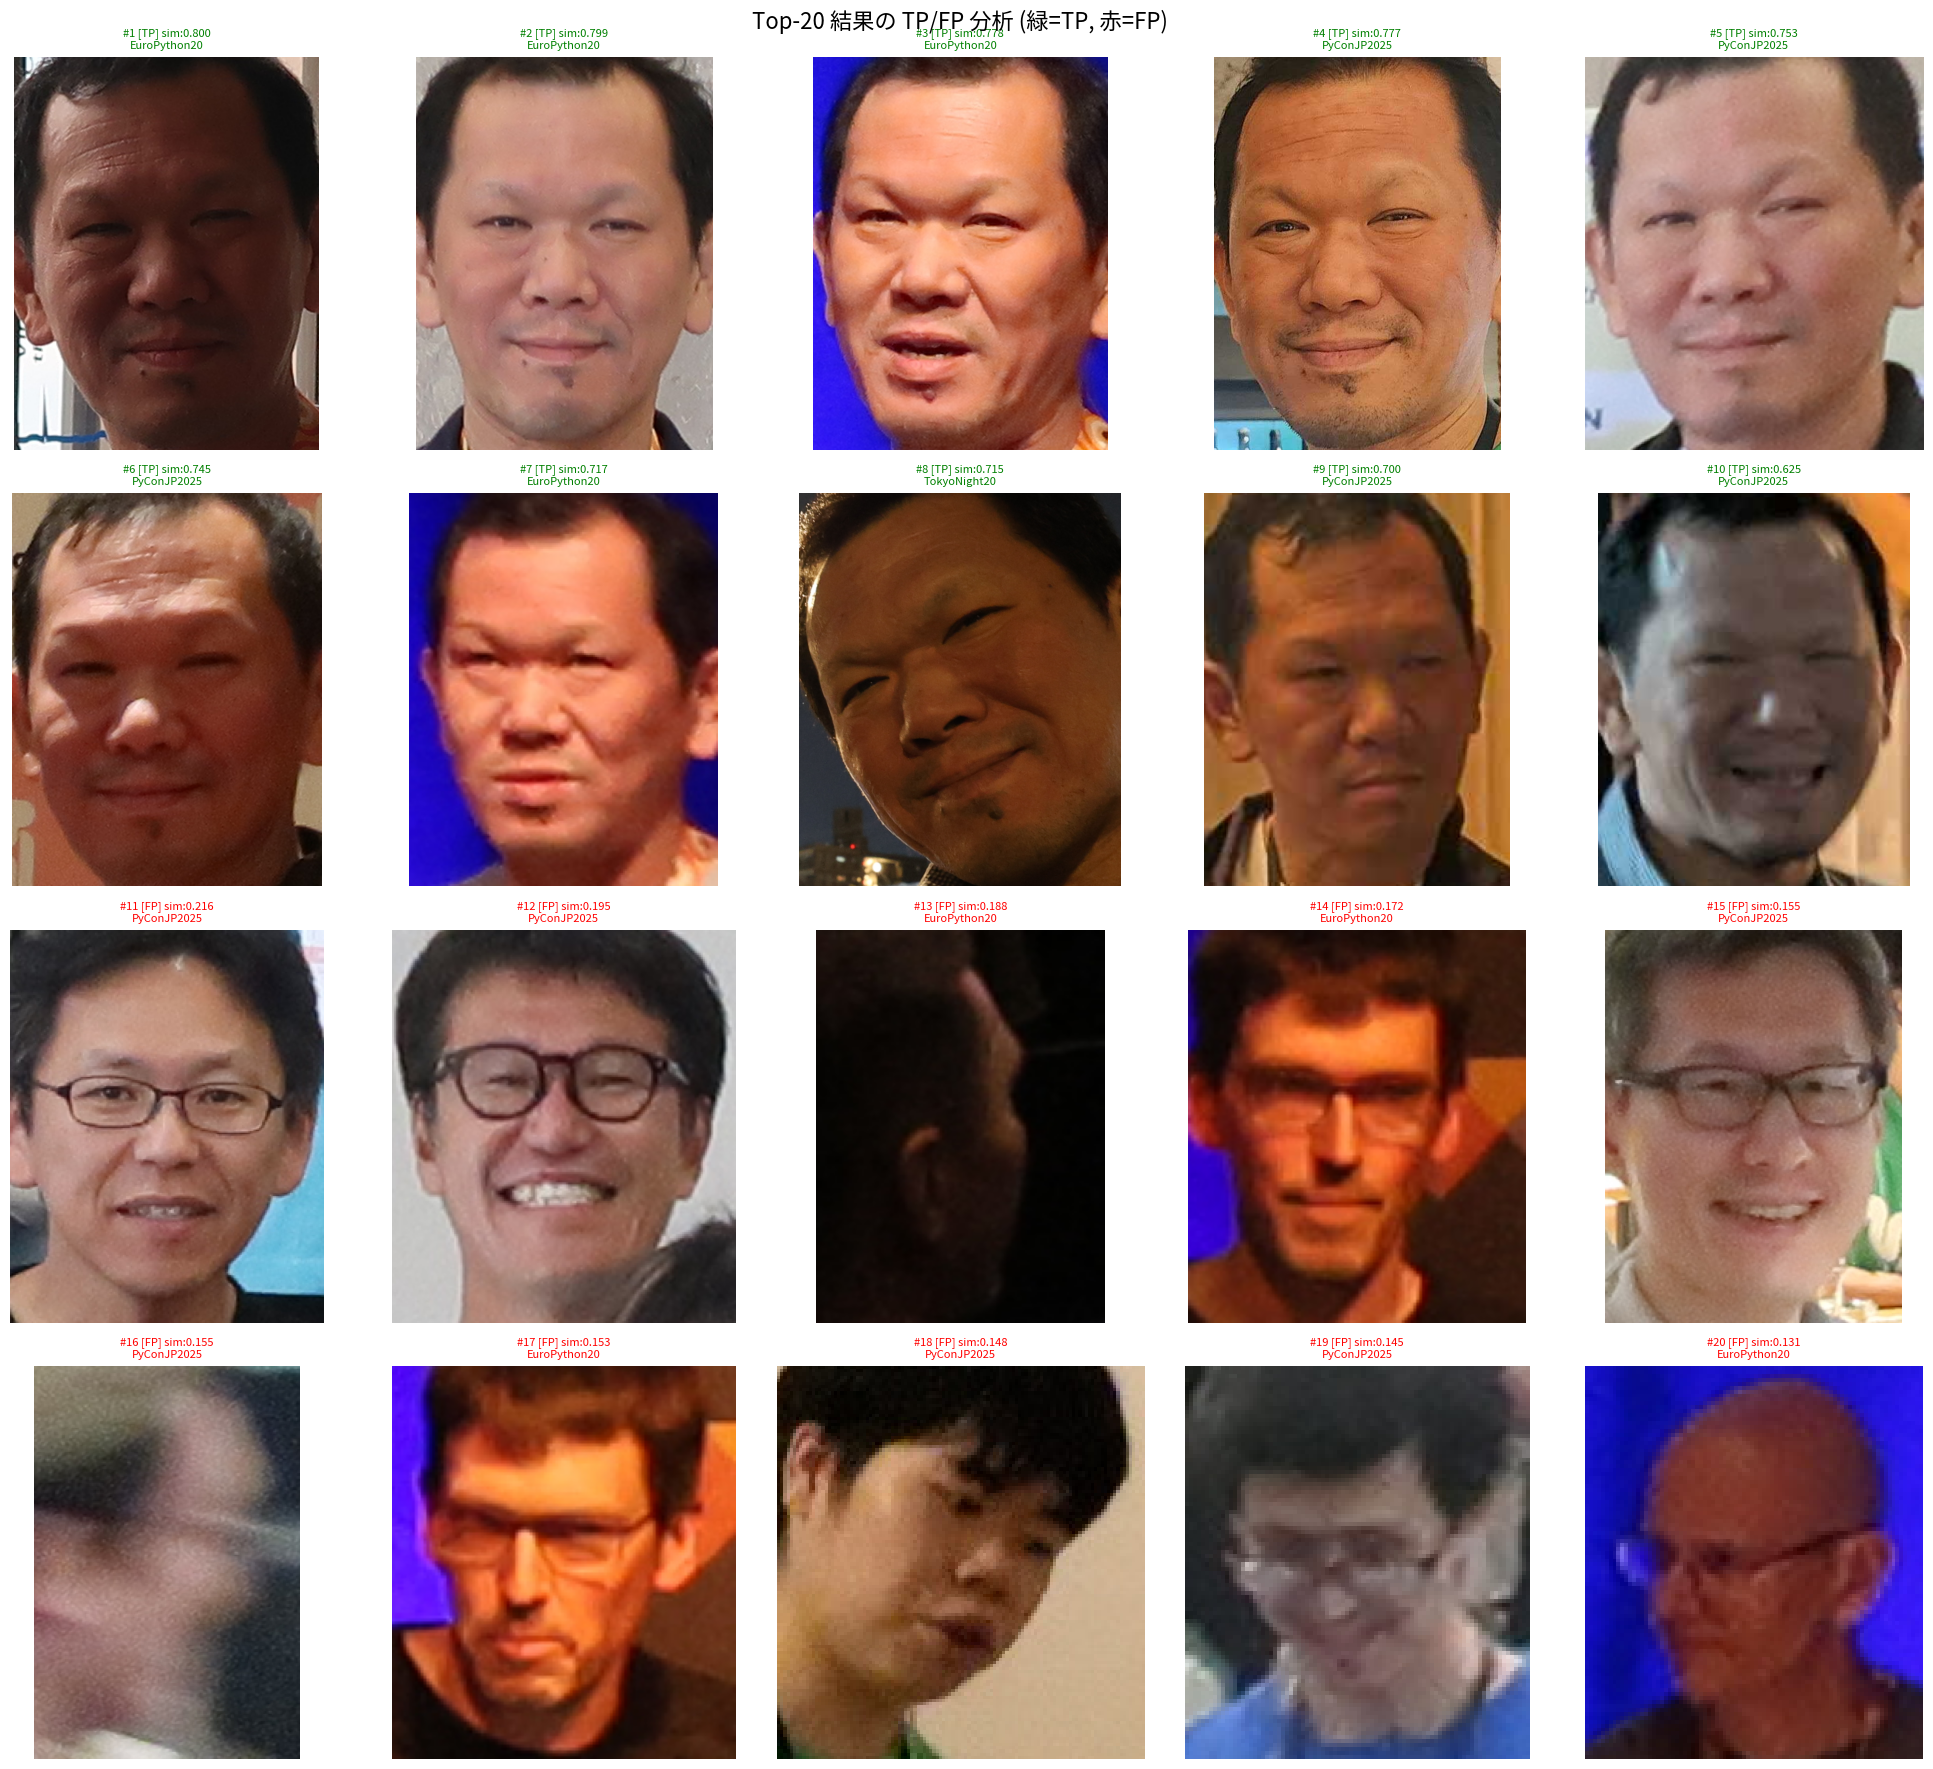

In [13]:
# 代表クエリ (最高スコアの terada) でFP/FN を詳しく分析
best_query = query_faces.iloc[0]
query_embedding = [float(x) for x in best_query["embedding"]]

# Top-20 結果を取得
top_results = conn.execute(f"""
    SELECT 
        f.face_id,
        c.file_name,
        c.file_path,
        c.category,
        f.person_label,
        f.bbox_x1, f.bbox_y1, f.bbox_x2, f.bbox_y2,
        array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}]) as distance
    FROM face_detections f
    JOIN image_catalog c ON f.image_id = c.id
    WHERE c.category != 'terada'
    ORDER BY distance
    LIMIT 20
""", [query_embedding]).fetchdf()

top_results["similarity"] = 1.0 - top_results["distance"]
top_results["is_relevant"] = top_results["face_id"].isin(relevant_set)

# FP: Top-K にいるが正解でない
fp = top_results[~top_results["is_relevant"]]
# TP: Top-K にいて正解
tp = top_results[top_results["is_relevant"]]

print(f"Top-20 結果: TP={len(tp)}, FP={len(fp)}")

# 表示
n_show = min(20, len(top_results))
cols = 5
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.5 * rows))
axes = np.array(axes).flatten()

for idx, (_, row) in enumerate(top_results.head(n_show).iterrows()):
    try:
        face_crop = crop_face(row["file_path"], row["bbox_x1"], row["bbox_y1"],
                              row["bbox_x2"], row["bbox_y2"])
        axes[idx].imshow(face_crop)
    except Exception:
        axes[idx].text(0.5, 0.5, "Error", ha="center", va="center", transform=axes[idx].transAxes)

    color = "green" if row["is_relevant"] else "red"
    label = "TP" if row["is_relevant"] else "FP"
    axes[idx].set_title(
        f"#{idx+1} [{label}] sim:{row['similarity']:.3f}\n{row['category'][:12]}",
        fontsize=8, color=color
    )
    axes[idx].axis("off")

for i in range(n_show, len(axes)):
    axes[i].axis("off")

plt.suptitle("Top-20 結果の TP/FP 分析 (緑=TP, 赤=FP)", fontsize=16)
plt.tight_layout()
plt.show()

## 最適閾値の決定 (ROC / F1)

全クエリの検索結果を統合して、最適な類似度閾値を決定する。

In [14]:
# 全クエリの全結果を取得（ラベル付き）
all_scored = []

for _, query_row in query_faces.iterrows():
    query_embedding = [float(x) for x in query_row["embedding"]]

    results = conn.execute(f"""
        SELECT 
            f.face_id,
            f.person_label,
            array_cosine_distance(f.embedding, ?::FLOAT[{EMBEDDING_DIM}]) as distance
        FROM face_detections f
        JOIN image_catalog c ON f.image_id = c.id
        WHERE c.category != 'terada'
        ORDER BY distance
        LIMIT 200
    """, [query_embedding]).fetchdf()

    results["similarity"] = 1.0 - results["distance"]
    results["is_relevant"] = results["face_id"].isin(relevant_set)
    all_scored.append(results)

df_scored = pd.concat(all_scored, ignore_index=True)

# 閾値ごとの指標
thresholds = np.arange(0.1, 0.8, 0.02)
thresh_metrics = []

for thresh in thresholds:
    predicted_positive = df_scored["similarity"] >= thresh
    tp = (predicted_positive & df_scored["is_relevant"]).sum()
    fp = (predicted_positive & ~df_scored["is_relevant"]).sum()
    fn = (~predicted_positive & df_scored["is_relevant"]).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    thresh_metrics.append({"threshold": thresh, "precision": precision, "recall": recall, "f1": f1})

df_thresh = pd.DataFrame(thresh_metrics)
best_f1_idx = df_thresh["f1"].idxmax()
best = df_thresh.iloc[best_f1_idx]

print(f"最適閾値: {best['threshold']:.2f}")
print(f"  Precision: {best['precision']:.3f}")
print(f"  Recall: {best['recall']:.3f}")
print(f"  F1: {best['f1']:.3f}")

最適閾値: 0.28
  Precision: 1.000
  Recall: 1.000
  F1: 1.000


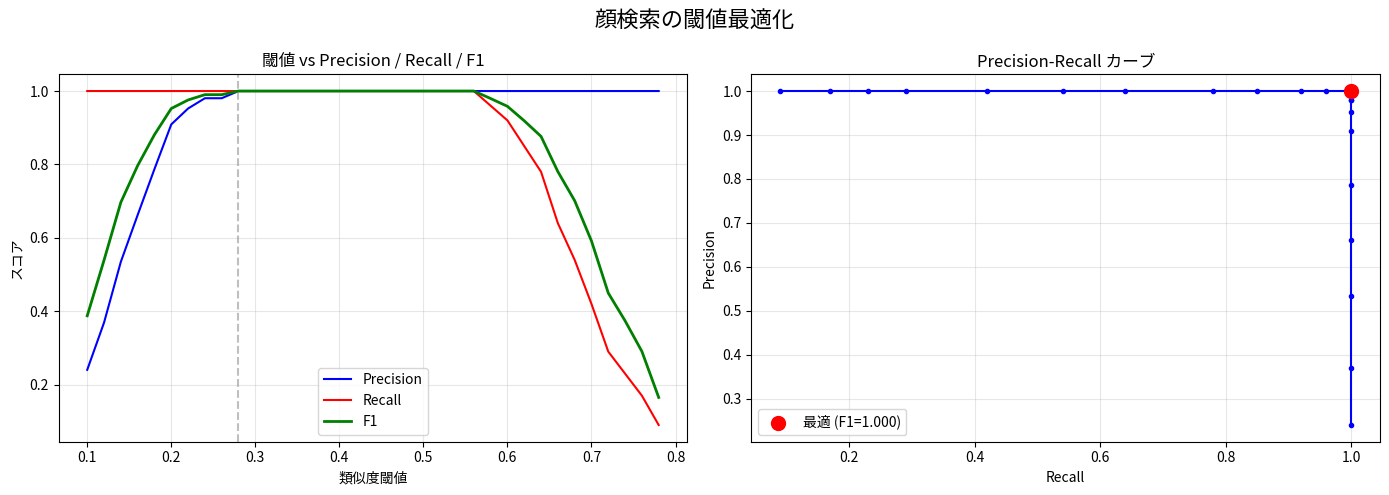

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 閾値 vs P/R/F1
ax1.plot(df_thresh["threshold"], df_thresh["precision"], "b-", label="Precision")
ax1.plot(df_thresh["threshold"], df_thresh["recall"], "r-", label="Recall")
ax1.plot(df_thresh["threshold"], df_thresh["f1"], "g-", linewidth=2, label="F1")
ax1.axvline(best["threshold"], color="gray", linestyle="--", alpha=0.5)
ax1.set_title("閾値 vs Precision / Recall / F1")
ax1.set_xlabel("類似度閾値")
ax1.set_ylabel("スコア")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Precision-Recall カーブ
ax2.plot(df_thresh["recall"], df_thresh["precision"], "b-o", markersize=3)
ax2.scatter([best["recall"]], [best["precision"]], color="red", s=100, zorder=5,
            label=f"最適 (F1={best['f1']:.3f})")
ax2.set_title("Precision-Recall カーブ")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("顔検索の閾値最適化", fontsize=16)
plt.tight_layout()
plt.show()

## まとめ

### 評価結果
- Ground Truth ラベルに基づく定量評価を実施
- Precision@K, Recall@K, MRR, mAP の各指標を算出
- 最適な類似度閾値を F1 スコアの最大化により決定
- False Positive / False Negative の傾向を分析

### 次のステップ
- **Notebook 56**: 検出モデルの比較（InsightFace vs MediaPipe vs DeepFace）

In [16]:
conn.close()
print("完了")

完了
